# Image Search Engine with CLIP Embeddings - Homework Assignment

![CLIP Architecture](https://github.com/openai/CLIP/raw/main/CLIP.png)

In this homework, you will implement an **Image Search Engine** using CLIP (Contrastive Language-Image Pre-training) embeddings on the Tiny-ImageNet validation dataset. CLIP allows you to search for images using both text queries and image queries.

## 📌 Project Overview
- **Task**: Build a multimodal image search engine
- **Architecture**: Pre-trained CLIP model for feature extraction
- **Dataset**: Tiny-ImageNet validation set
- **Goal**: Retrieve most similar images given text or image queries

## 📚 Learning Objectives
By completing this assignment, you will:
- Understand multimodal embeddings and their applications
- Learn to use pre-trained CLIP models for feature extraction
- Implement similarity search using cosine similarity
- Evaluate zero-shot classification performance
- Build a practical image retrieval system

## 1️⃣ Dataset Setup

**Task**: Download and explore the Tiny-ImageNet validation dataset.

**Requirements**:
- Install the tinyimagenet package
- Load the validation split of the dataset
- Explore the dataset structure and class labels
- Visualize sample images from different classes

100%|██████████| 248M/248M [00:06<00:00, 38.6MB/s]


Dataset loaded successfully. Total Image: 10000
{0: ['goldfish', ' Carassius auratus'], 1: ['European fire salamander', ' Salamandra salamandra'], 2: ['bullfrog', ' Rana catesbeiana'], 3: ['tailed frog', ' bell toad', ' ribbed toad', ' tailed toad', ' Ascaphus trui'], 4: ['American alligator', ' Alligator mississipiensis'], 5: ['boa constrictor', ' Constrictor constrictor'], 6: ['trilobite'], 7: ['scorpion'], 8: ['black widow', ' Latrodectus mactans'], 9: ['tarantula'], 10: ['centipede'], 11: ['goose'], 12: ['koala', ' koala bear', ' kangaroo bear', ' native bear', ' Phascolarctos cinereus'], 13: ['jellyfish'], 14: ['brain coral'], 15: ['snail'], 16: ['slug'], 17: ['sea slug', ' nudibranch'], 18: ['American lobster', ' Northern lobster', ' Maine lobster', ' Homarus americanus'], 19: ['spiny lobster', ' langouste', ' rock lobster', ' crawfish', ' crayfish', ' sea crawfish'], 20: ['black stork', ' Ciconia nigra'], 21: ['king penguin', ' Aptenodytes patagonica'], 22: ['albatross', ' molly

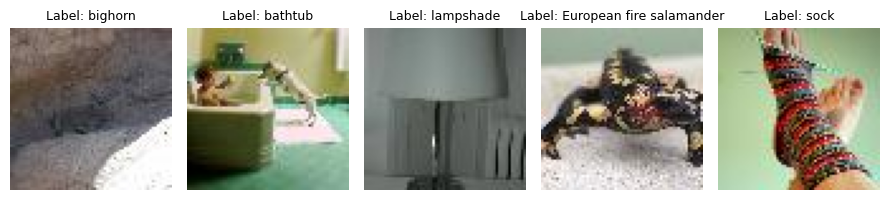

In [ ]:
# TODO: Install tinyimagenet package (uncomment the line below)
!pip install tinyimagenet

# TODO: Import necessary libraries
import os
import tinyimagenet
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
# TODO: Load the validation dataset
# define the root first
ROOT = Path(f"/content")
tiny_imagenet = tinyimagenet.TinyImageNet(ROOT, split='val')
# TODO: Print dataset information
"""
instruction avaliable: https://huggingface.co/datasets/zh-plus/tiny-imagenet
Data structures:
{
  'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=64x64 at 0x1A800E8E190,
  'label': 15
}
"""
print(f"Dataset loaded successfully. Total Image: {len(tiny_imagenet)}")
# here the path should point to '/content/tiny-imagenet-200'
# and the input should be 'path object' instead of str
words, classes = tiny_imagenet.load_words_classes(Path(os.path.join(ROOT, "tiny-imagenet-200")))
print(words)
print(classes)
print(f"There are #{len(classes)} of classes")
# TODO: Display 5 sample images with their class information
fig, axes = plt.subplots(1, 5, figsize=(9, 9))
axes = axes.flatten()
for _ , ax in enumerate(axes):
    img, label = tiny_imagenet.__getitem__(random.randint(0, 9999))
    # print(label)
    img = img.cpu().detach().numpy()
    # display the image
    if img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Label: {words[label][0]}', fontsize=9)

plt.tight_layout()
plt.show()

##Note:
Since I didn't overwrite `__getitem__()` method, the default return type is `torch.Tensor` (normalized). However, the pre-train model only supports image input. So, I have to convert `torch.Tensor` to `PIL.Image`.

## 2️⃣ Import Libraries and Configuration

**Task**: Import all necessary libraries and set up the environment for CLIP.

**Requirements**:
- Import PyTorch, transformers, and other necessary libraries
- Load the pre-trained CLIP model and processor
- Set up device configuration (GPU if available)
- Configure any necessary parameters

In [ ]:
# TODO: Import all necessary libraries
import torch
import torchvision
import torch.nn as nn
from tqdm import tqdm
from torchvision.transforms import ToPILImage
# here, we need not to install 'clip' module
# because transformers has already provide us CLIP model and processor
from transformers import CLIPProcessor, CLIPModel
# TODO: Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device: {device}")
# TODO: Load pre-trained CLIP model and processor
"""
Documentation available: https://huggingface.co/transformers/v4.6.0/model_doc/clip.html
For the model I tried, more info available: https://huggingface.co/openai/clip-vit-base-patch32
"""
model_name = f"openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)
# TODO: Move model to device
model = model.to(device)
model.eval()
# TODO: Print model information
print(model.config)

using device: cuda


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPConfig {
  "architectures": [
    "CLIPModel"
  ],
  "dtype": "float32",
  "initializer_factor": 1.0,
  "logit_scale_init_value": 2.6592,
  "model_type": "clip",
  "projection_dim": 512,
  "text_config": {
    "add_cross_attention": false,
    "attention_dropout": 0.0,
    "bos_token_id": 0,
    "cross_attention_hidden_size": null,
    "decoder_start_token_id": null,
    "dropout": 0.0,
    "dtype": "float32",
    "eos_token_id": 2,
    "finetuning_task": null,
    "hidden_act": "quick_gelu",
    "hidden_size": 512,
    "initializer_factor": 1.0,
    "initializer_range": 0.02,
    "intermediate_size": 2048,
    "is_decoder": false,
    "layer_norm_eps": 1e-05,
    "max_position_embeddings": 77,
    "model_type": "clip_text_model",
    "num_attention_heads": 8,
    "num_hidden_layers": 12,
    "pad_token_id": 1,
    "prefix": null,
    "projection_dim": 512,
    "pruned_heads": {},
    "sep_token_id": null,
    "task_specific_params": null,
    "tie_encoder_decoder": false,
    "tie

## 3️⃣ Feature Extraction from Dataset

**Task**: Extract CLIP embeddings for all images in the validation dataset.

**Requirements**:
- Process all validation images through CLIP
- Extract and store image embeddings
- Normalize embeddings for cosine similarity computation
- Save embeddings for efficient searching

Reference available: https://medium.com/@prestonrozwood/exploring-image-embeddings-with-clip-a-beginners-guide-e179ee3d3f88

In [ ]:
# TODO: Create function to extract image embeddings
def extract_img(dataset):
    """
    Argument:
      - dataset: dataset that include images
    Return:
      - images: images extracted from dataset
    """
    num_images = dataset.__len__()
    to_pil = ToPILImage()
    images = []
    for index in range(num_images):
        img_tensor = dataset.__getitem__(index)[0]
        if isinstance(img_tensor, torch.Tensor):
            # convert tensor to PIL image
            image = to_pil(img_tensor)
        else:
            image = img_tensor
        images.append(image)
    return images
def extract_img_embedding(model, processor, images, device, batch_size=32):
    """
    Arguments:
      - model: the model you use
      - processor: the processor you use
      - images: the image you want to embed
      - device: the device you use
      - batch_size: batch size (default 16)
    Return:
      - embeddings (dtype: numpy array): extracted features from image
    """
    num_images = images.__len__()
    embeddings = []
    with torch.no_grad():
      for i in tqdm(range(0, num_images, batch_size), desc="Extract features"):
        # TODO: Collect batch of images
        batch = images[i : i+batch_size]
        # TODO: Process batch through CLIP
        # Note: our batch is on CPU now, we need move it to GPU
        input = processor(images=batch, return_tensors='pt', padding=True).to(device)
        image_features = model.get_image_features(**input)
        # Normalization:
        if not isinstance(image_features, torch.Tensor):
          # extract features from returned object
          image_features = image_features.pooler_output
        image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
        # convert to numpy array
        image_features = image_features.cpu().numpy()
        # TODO: Print progress
        # solved by tqdm
        # store the features in embeddings:
        embeddings.append(image_features)
      # TODO: Concatenate all embeddings
      embeddings = np.concatenate(embeddings, axis=0)
    return embeddings
# TODO: Extract embeddings for the validation dataset
model.eval()
images = extract_img(tiny_imagenet)
img_embeddings = extract_img_embedding(model, processor, images, device)

Extract features: 100%|██████████| 313/313 [00:33<00:00,  9.38it/s]


In [ ]:
# save embeddings to certain file:
# in case I run out quota...
SAVE_DIR = f"/content"
img_save_path = os.path.join(SAVE_DIR, "img_embeddings.txt")
np.savetxt(img_save_path, img_embeddings)

## 4️⃣ Zero-Shot Classification Evaluation

**Task**: Evaluate CLIP's zero-shot classification performance on Tiny-ImageNet.

**Requirements**:
- Create text prompts for each image in Tiny-ImageNet
    - Check the dataset words.txt!!!!
- Extract text embeddings for class descriptions
- Perform zero-shot classification using similarity matching
- Calculate and report accuracy metrics

Reference available: https://medium.com/@myscale/zero-shot-classification-with-openais-clip-6c50c25cf094

In [ ]:
# load the image embeddings:
img_embeddings = np.loadtxt(img_save_path)

In [ ]:
# TODO: Create text prompts for all classes
# Not for each Image!
def create_text_prompts(dataset):
    """
    Arguments:
      - dataset: the validation dataset (tiny_imagenet)
    Return:
      - list[str]
    Note:
    The structure of words:
    {0: ['goldfish', 'Carassius auratus'], 1: ['European fire salamander', ' Salamandra salamandra'], ...}
    """
    words, classes = dataset.load_words_classes(Path(os.path.join(ROOT, "tiny-imagenet-200")))
    prompts = []
    for index in range(len(words)):
      prompts.append(f"A photo of a {words[index][0]}")
    print(f"Created {len(prompts)} prompts for {len(words)} classes")
    return prompts
# create text prompts for all classes:
text_prompts = create_text_prompts(tiny_imagenet)

# TODO: Extract text embeddings for class prompts
# We have to process the embedding in batches
# Otherwise, Cuda OOM issue would come
def extract_text_embedding(model, processor, texts, device, batch_size=200):
    """
    Arguments:
      - model: the model you use
      - processor: the processor you use
      - texts: dataset that include text prompts
      - device: the device you use
      - batch_size: batch size (default 16)
    Return:
      - embeddings (dtype: numpy array): extracted features from text
    """
    text_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting features"):
        batch = processor(text=texts[i : i+batch_size], return_tensors='pt', padding=True).to(device)
        model.eval()
        with torch.no_grad():
            outputs = model.get_text_features(**batch)
            # normalization:
            if not isinstance(outputs, torch.Tensor):
                # extract features from returned object
                outputs = outputs.pooler_output
            outputs = outputs / outputs.norm(p=2, dim=-1, keepdim=True)
            # convert to numpy
            outputs = outputs.cpu().numpy()
            # add it to text_embeddings
            text_embeddings.append(outputs)
    # Concate all embeddings
    text_embeddings = np.concatenate(text_embeddings, axis=0)
    return text_embeddings
# TODO: Perform zero-shot classification
text_embeddings = extract_text_embedding(model, processor, text_prompts, device)

# TODO: Calculate similarities and predictions
similarity_matrix = np.dot(img_embeddings, text_embeddings.T)
preds = np.argmax(similarity_matrix, axis=1)
# TODO: Calculate accuracy
correct_count = 0
for i in range(len(img_embeddings)):
  _, correct_label = tiny_imagenet.__getitem__(i)
  if correct_label == preds[i]:
    correct_count += 1
  else:
    continue

accuracy = correct_count / len(img_embeddings)
print(f"Accuracy is: {accuracy * 100:.2f}%")

Created 200 prompts for 200 classes


Extracting features: 100%|██████████| 1/1 [00:00<00:00,  5.29it/s]


Accuracy is: 60.66%


## 5️⃣ Image Search Engine Implementation

**Task**: Build functions to search for similar images using both text and image queries.

**Requirements**:
- Implement text-to-image search functionality
- Implement image-to-image search functionality
- Return top-k most similar images
- Create visualization functions for search results

In [ ]:
# TODO: Implement text-to-image search
def Text2Image_search(model, processor, device, text, top_k=5, img_emb=img_embeddings):
  """
  Arguments:
    - model: the model you want to use
    - processor: the processor you want to use
    - device: the device you use
    - text: the text (prompt) you search for
    - top_k: number of most similar images you want
    - img_emb: the image set you search (embedded!)
  Return:
    List of indices of predicted images
  """
  # extract text embedding from 'text'
  text_embedding = extract_text_embedding(model, processor, text, device, 1)
  # calculate the similarity scores
  scores = np.dot(text_embedding, img_emb.T)    # shape: (len(text), len(img_embeddings))
  # sort in ascending order
  preds = np.argsort(scores, axis=-1)
  preds = np.flip(preds, axis=-1)
  return preds[:, 0:top_k]

# TODO: Implement image-to-image search
def Image2Image_search(model, processor, device, img, top_k=5, img_emb=img_embeddings):
  """
  Arguments:
    - model: the model you want to use
    - processor: the processor you want to use
    - device: the device you use
    - img: the image you search for
    - top_k: number of most similar images you want
    - img_emb: the image set you search (embedded!)
  Return:
    List of indices of predicted images
  """
  # extract image embedding from 'img'
  img_embedding = extract_img_embedding(model, processor, img, device, 1)
  # calculate the similarity scores
  scores = np.dot(img_embedding, img_emb.T)
  # sort in ascending order
  preds = np.argsort(scores, axis=-1)
  preds = np.flip(preds, axis=-1)
  return preds[:, 0:top_k]
# TODO: Create visualization function
def visualization(img_index, dataset=tiny_imagenet, figsize=(8, 8)):
  """
  Argument:
    - img_index: the predicted indices
    - dataset: used to find corresponding image
    - figsize: the figure size for each image
  """
  num_img = len(img_index)
  fig, axes = plt.subplots(1, num_img, figsize=figsize)
  axes = axes.flatten()
  counter = 0
  for _ , ax in enumerate(axes):
    img, label = tiny_imagenet.__getitem__(img_index[counter])
    img = img.cpu().detach().numpy()
    # display the image
    if img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Label: {words[label][0]}', fontsize=9)
    counter += 1

  plt.tight_layout()
  plt.show()

## 6️⃣ Testing with Custom Queries

**Task**: Test your search engine with custom text queries and web images.

**Requirements**:
- Test with 5 different text queries
- Download and test with 5 images from the web
- Display top 5 most similar images for each query
- Analyze the quality of retrieved results

In [ ]:
# TODO: Test with text queries
text_queries = [
    "A photo of a cat",
    "A photo of a lion",
    "A photo of a hotdog",
    "A photo of a phone",
    "A photo of a desk"
]

Start Text to Image Search


Extracting features: 100%|██████████| 5/5 [00:00<00:00, 39.99it/s]


Find image: A photo of a cat by Text2Image Search


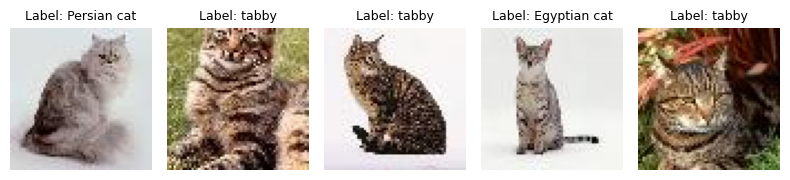


Find image: A photo of a lion by Text2Image Search


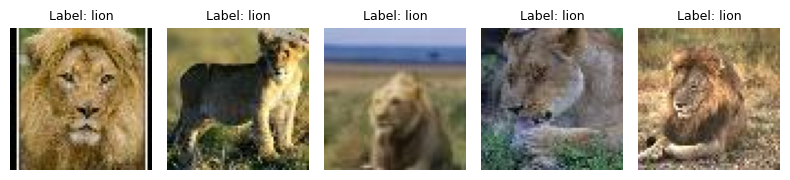


Find image: A photo of a hotdog by Text2Image Search


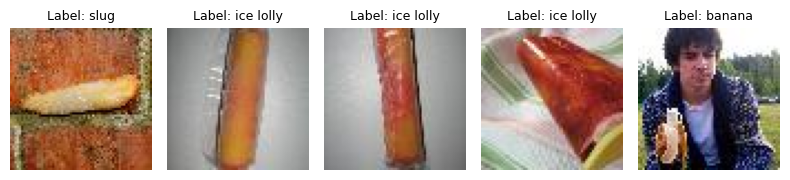


Find image: A photo of a phone by Text2Image Search


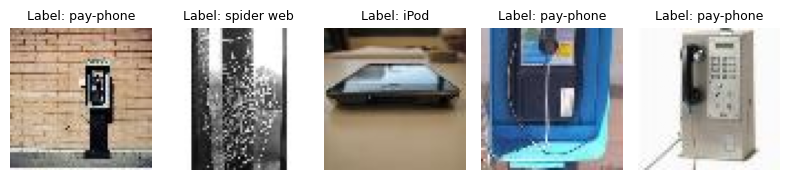


Find image: A photo of a desk by Text2Image Search


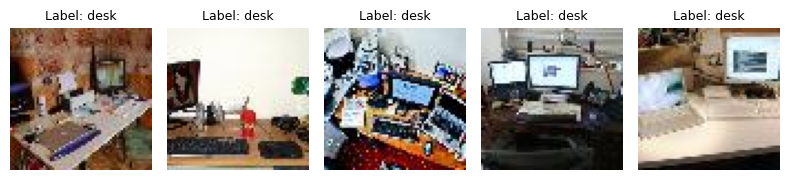


Start Image to Image Search


Extract features: 100%|██████████| 5/5 [00:00<00:00, 40.83it/s]


Find image: A photo of a cat by Image2Image Search


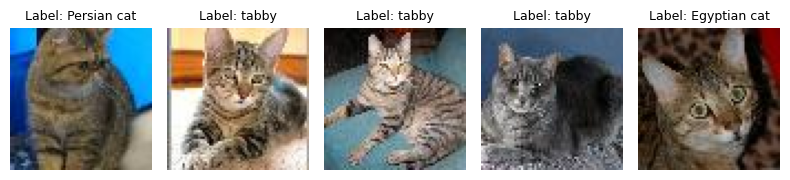


Find image: A photo of a lion by Image2Image Search


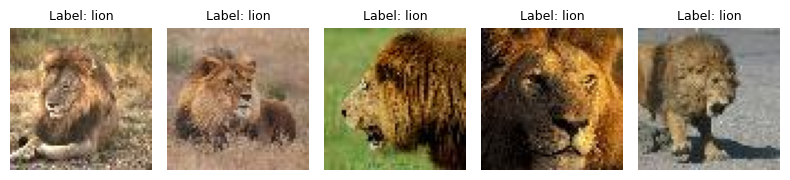


Find image: A photo of a hotdog by Image2Image Search


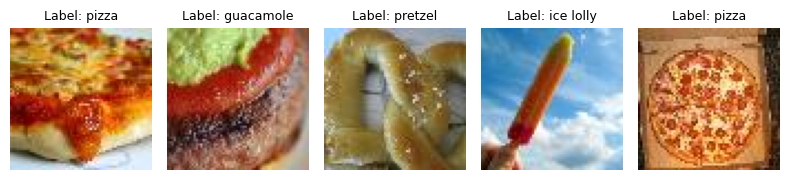


Find image: A photo of a phone by Image2Image Search


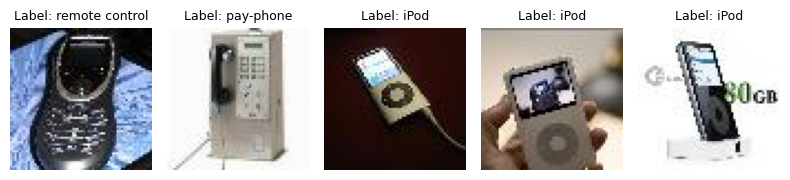


Find image: A photo of a desk by Image2Image Search


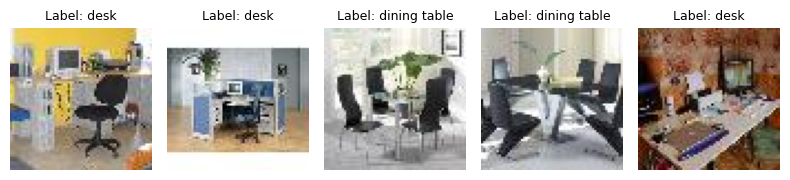

In [ ]:
# TODO: Test with image queries from web
import requests
from PIL import Image
from io import BytesIO
def load_img_from_web(urls):
    """
    Argument:
      - urls: url of the image
    Return:
      - images: list of image
    """
    images = []
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    for url in urls:
        try:
            response = requests.get(url, headers=headers, stream=True)
            response.raise_for_status()
            img = Image.open(BytesIO(response.content)).convert("RGB")
            images.append(img)
        except Exception as e:
            print(f"Error downloading {url}")

    return images
# TODO: Define image URLs for testing
URLs = [
    "https://images.pexels.com/photos/2071882/pexels-photo-2071882.jpeg?auto=compress&cs=tinysrgb&dpr=1&w=500", # cat
    "https://i.pinimg.com/originals/c7/a8/80/c7a880385f375141050e14083f38e8a4.jpg", # lion
    "https://tse4.mm.bing.net/th/id/OIP.AYHg0oeg2JjS-khNQ1j_tgHaHa?r=0&rs=1&pid=ImgDetMain&o=7&rm=3", # hotdog
    "https://media.istockphoto.com/id/172803264/photo/modern-mobile-phone.jpg?s=1024x1024&w=is&k=20&c=cR89aSa5xkn62IqHGOdpfBQPqE6XZXh9OIq8nHVH2k8=", # phone
    "https://cdn.pixabay.com/photo/2023/11/10/20/37/desk-8380078_1280.jpg" # desk
]
images = load_img_from_web(URLs)
print(f"Start Text to Image Search")
img_indices = Text2Image_search(model, processor, device, text_queries)
for i in range(len(text_queries)):
    print(f"\nFind image: {text_queries[i]} by Text2Image Search")
    visualization(img_indices[i])

print(f"\nStart Image to Image Search")
img_indices = Image2Image_search(model, processor, device, images)
for i in range(len(text_queries)):
    print(f"\nFind image: {text_queries[i]} by Image2Image Search")
    visualization(img_indices[i])

##Analyse
As you can see, the model cannot predict 'hotdog' well. I guess that it's because there is no 'hotdog' in the training dataset (maybe also in the validation dataset). So, all prediction for hotdog is wrong.

Also, notive that for Text2Image Search, it prefers objects with 'long cylinder' shape. But for Image2Image Search, it focues on the color more (pizza and hotdog both have 'red' color). And I think in paper: How far is Video Generation from World Model (available: https://arxiv.org/abs/2411.02385). It mentions the same idea (Video models prefer color more than shape. I guess since my text doesn't provide any color info, so model focues on 'shape'.)

## 📝 Evaluation Criteria

Your homework will be evaluated based on:

1. **Implementation Correctness (40%)**
   - Proper CLIP model loading and usage
   - Correct feature extraction for images and text
   - Working search functionality for both text and image queries
   - Accurate zero-shot classification implementation

2. **Search Results Quality (30%)**
   - Reasonable search results for text queries
   - Appropriate image-to-image search results
   - Correct similarity calculations and ranking
   - Zero-shot classification accuracy

3. **Code Quality (20%)**
   - Clean, readable code with proper comments
   - Efficient implementation with batch processing
   - Proper error handling and edge cases
   - Well-structured functions

4. **Testing and Demonstration (10%)**
   - Successful testing with custom queries
   - Clear visualization of search results
   - Proper documentation of testing process